In [1]:
import numpy as np
import cupy as cp
from cupyx.scipy import ndimage
from tanalysis import improcess
import matplotlib.pyplot as plt
import tifffile as tiff
from skimage.measure import label, regionprops
from skimage.feature import blob_log

In [2]:
def LoG(sigma_x, sigma_y, sigma_z):
    #n = cp.ceil(max(sigma_x, sigma_y, sigma_z)*6)
    n = 7
    z,y,x = cp.ogrid[-n//2:n//2+1, -n//2:n//2+1, -n//2:n//2+1]
    z_filter = cp.exp(-(z*z/(2*sigma_z**2)))
    y_filter = cp.exp(-(y*y/(2*sigma_y**2)))
    x_filter = cp.exp(-(x*x/(2*sigma_x**2)))
    final_filter = -(1/(sigma_x*sigma_y*sigma_z*(2*np.pi)**(3/2)))*((1-x*x/(sigma_x**2))/(sigma_x**2)+(1-y*y/(sigma_y**2))/(sigma_y**2)+(1-z*z/(sigma_z**2))/(sigma_z**2))*(z_filter*x_filter*y_filter)
    return final_filter

In [3]:
def LoG_convolve(img, sigmas:list):
    filter_log = LoG(*sigmas)
    image = ndimage.convolve(img, filter_log)
    #image = cp.pad(image, ((1,1,1),(1,1,1)), 'constant')
    image = cp.square(image)
    return cp.asarray(image)

In [4]:
def gaussian(sigma_x, sigma_y, sigma_z):
    n = 7
    z,y,x = cp.ogrid[-n//2:n//2+1, -n//2:n//2+1, -n//2:n//2+1]
    z_filter = cp.exp(-(z*z/(2*sigma_z**2)))
    y_filter = cp.exp(-(y*y/(2*sigma_y**2)))
    x_filter = cp.exp(-(x*x/(2*sigma_x**2)))
    final_filter = (x_filter*y_filter*z_filter)/(sigma_x*sigma_y*sigma_z*(2*np.pi)**(3/2))
    return final_filter

In [5]:
dirname = r"C:\Users\pcanaleta\Documents\Cellpose_segmentation\EXP.HD6.Chips\EXP.HD6.1.2.Test\EXP.HD6.1.2.Test.0\24h\Stitched\24h_chem20_thunder-0.tiff"
imgs, names, info = improcess.imread(dirname, False, False)

In [17]:
T,D,H,W = imgs[0].shape
result = np.empty(shape=(T,D,H,W), dtype=np.int8)
sigmas = [6, 6, 0.001]
gauss_filt = gaussian(3,3,0.1)
t=0
for img in imgs[0]:
    img = cp.array(img)
    th = cp.max(img)
    img_th = img>int(th*0.1)
    log_img_th = LoG_convolve(img_th, sigmas)
    res_img_np = ndimage.convolve(log_img_th, gauss_filt)
    res_img_np = cp.asnumpy(res_img_np)
    #res_img_np = label(res_img_np)
    result[t] = res_img_np
    t += 1

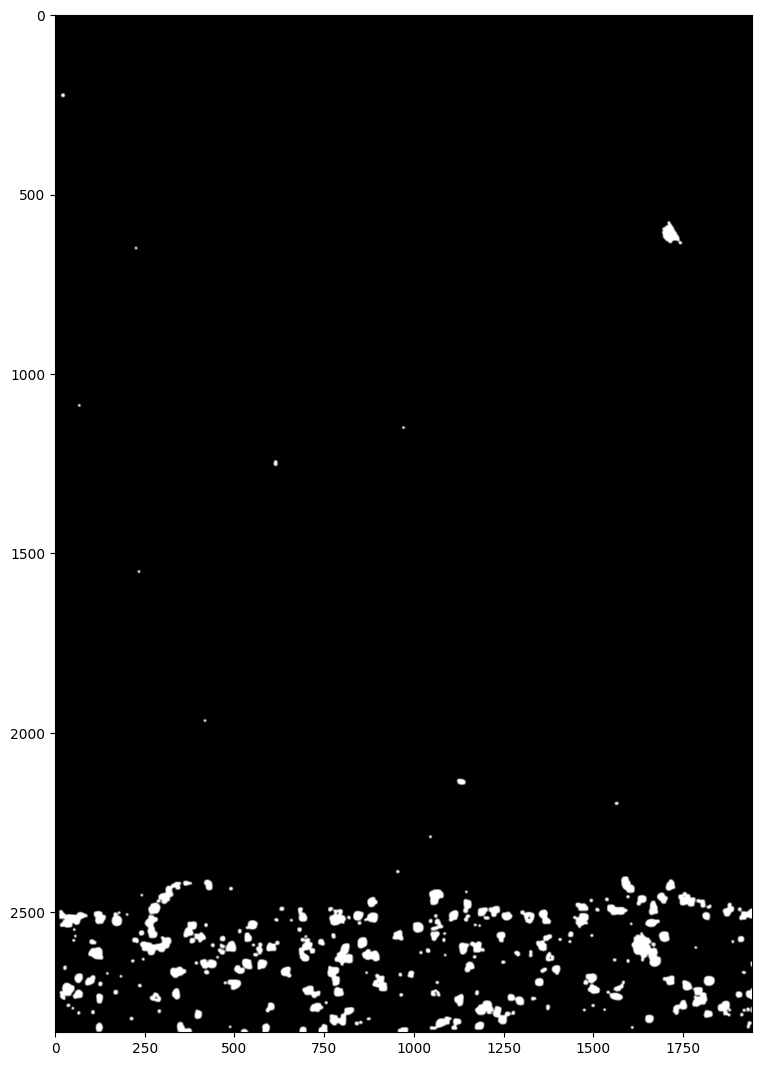

In [19]:
im = cp.asnumpy(result[0])

plt.figure(figsize=(9,16))
plt.imshow(im[4], cmap='gray')
plt.show()

In [ ]:
result_img = cp.asnumpy(result)
result_img = 255*np.uint8(result_img)
tiff.imwrite(r"C:\Users\pcanaleta\Desktop\Test\test.tiff", 
            result_img, 
            imagej=True,
            metadata={
                'axes':"TZYX"
            })